In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_minimum_distances)=
# Get minimum distances

*Calculating minimum spatial distances between atom selections or molecular groups.*

The function {func}`molsysmt.structure.get_minimum_distances` calculates the closest distance and identifies the closest atom pair between two groups of atoms across single or multiple trajectory structures.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.get_minimum_distances`.
:::


## Basic usage

Let's show how to calculate the minimum distance between two atom sets over a pentalanine trajectory (illustrated using terminal residues 0 and 4):


In [2]:
import molsysmt as msm
import matplotlib.pyplot as plt
import pyunitwizard as puw


In [3]:
molsys = msm.convert(msm.systems['pentalanine']['traj_pentalanine.h5msm'])


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We compute the minimum distance between the two selections using {func}`molsysmt.structure.get_minimum_distances`:


In [4]:
pairs, min_distances = msm.structure.get_minimum_distances(molsys, selection='group_index==0', selection_2='group_index==4')


In [5]:
print('Pairs array shape:', pairs.shape)
print('Minimum distances shape:', min_distances.shape)
print(f'Minimum distance at frame 0: {min_distances[0]:.3f} (between atom {pairs[0,0]} and {pairs[0,1]})')


Pairs array shape: (5000, 2)
Minimum distances shape: (5000,)
Minimum distance at frame 0: 0.823 nanometer (between atom 4 and 3)


## Plotting minimum distance time series

We plot the evolution of the minimum inter-set distance over simulation time:


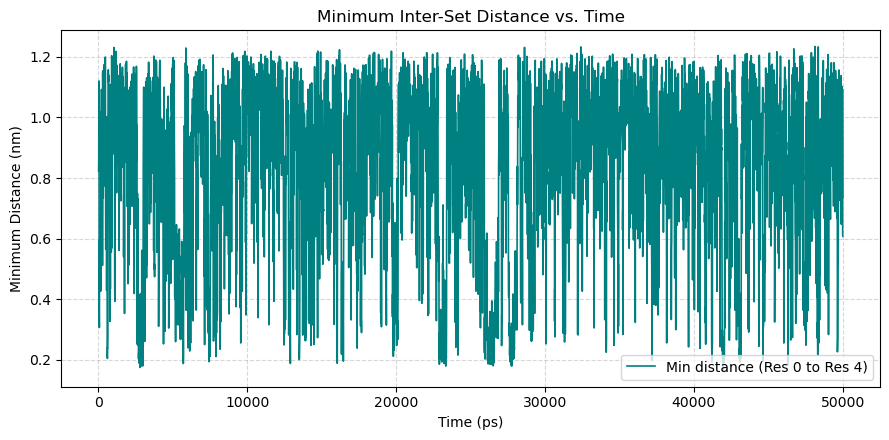

In [6]:
time = msm.get(molsys, element='system', time=True)
time_val = puw.get_value(time, to_unit='ps')
dist_val = puw.get_value(min_distances, to_unit='nm')

plt.figure(figsize=(9, 4.5))
plt.plot(time_val, dist_val, color='teal', lw=1.2, label='Min distance (Res 0 to Res 4)')
plt.xlabel('Time (ps)')
plt.ylabel('Minimum Distance (nm)')
plt.title('Minimum Inter-Set Distance vs. Time')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## Finding the closest atom in a target set

Setting `as_entity=False` and `as_entity_2=True` queries, for each atom in `selection`, the closest atom in `selection_2`:


In [7]:
pairs_ind, min_d_ind = msm.structure.get_minimum_distances(molsys, selection='group_index==0 and atom_type!="H"', selection_2='group_index==4 and atom_type!="H"', as_entity=False, as_entity_2=True)
print('Shape of individual atom minimum distances:', min_d_ind.shape)
print(f'Closest target atom for first atom at frame 0: target atom index {pairs_ind[0, 0]} at distance {min_d_ind[0, 0]:.3f}')


Shape of individual atom minimum distances: (5000, 3)
Closest target atom for first atom at frame 0: target atom index 0 at distance 0.977 nanometer


## Computing minimum distances between atom sets

We can compute the global minimum non-bonded distance between two independent macro-selections (illustrated here using two protein chains in TcTIM):


In [8]:
tctim = msm.convert(msm.systems['TcTIM']['1tcd.h5msm'])
pairs_chains, min_dist_chains = msm.structure.get_minimum_distances(tctim, selection='chain_index==0 and atom_type!="H"', selection_2='chain_index==1 and atom_type!="H"')
print(f'Closest inter-chain contact distance: {min_dist_chains[0]:.3f}')
print(f'Closest contact atoms: atom {pairs_chains[0,0]} (chain 0) and atom {pairs_chains[0,1]} (chain 1)')


Closest inter-chain contact distance: 0.254 nanometer
Closest contact atoms: atom 552 (chain 0) and atom 729 (chain 1)


## Computing minimum distances between group centers

Passing `center_of_atoms=True` and `center_of_atoms_2=True` finds the minimum distance between the geometric centroids of atom groups (e.g. between all residue centers of two chains):


In [9]:
groups_0 = msm.get(tctim, element='group', selection='chain_index==0', atom_index=True)
groups_1 = msm.get(tctim, element='group', selection='chain_index==1', atom_index=True)
pairs_cent, min_d_cent = msm.structure.get_minimum_distances(tctim, selection=groups_0, selection_2=groups_1, center_of_atoms=True, center_of_atoms_2=True)
print(f'Closest residue centers distance: {min_d_cent[0]:.3f} (between residue {pairs_cent[0,0]} and {pairs_cent[0,1]})')


Closest residue centers distance: 0.382 nanometer (between residue 69 and 12)


## Measuring minimum displacements across structures

Using `pairs=True` between different structure indices identifies the atom that experienced the minimum displacement between consecutive time frames:


In [10]:
pairs_disp, min_disp = msm.structure.get_minimum_distances(molsys, structure_indices=[0, 1], structure_indices_2=[1, 2], pairs=True)
print(f'Atom {pairs_disp[0]} had the minimum displacement ({min_disp[0]:.4f}) between frames 0 and 1.')
print(f'Atom {pairs_disp[1]} had the minimum displacement ({min_disp[1]:.4f}) between frames 1 and 2.')


Atom 45 had the minimum displacement (0.0734 nanometer) between frames 0 and 1.
Atom 35 had the minimum displacement (0.2984 nanometer) between frames 1 and 2.


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Get <Tutorial_Get>`: Query system time and structural attributes with {func}`molsysmt.basic.get`.
- {ref}`Get distances <Tutorial_Get_distances>`: Compute full pairwise distance matrices and element distances with {func}`molsysmt.structure.get_distances`.
- {ref}`Get maximum distances <Tutorial_Get_maximum_distances>`: Find the maximum span or diameter between elements with {func}`molsysmt.structure.get_maximum_distances`.
- {ref}`Get contacts <Tutorial_Get_contacts>`: Determine boolean contact matrices within a distance threshold with {func}`molsysmt.structure.get_contacts`.
:::
